# LieselOptim: advanced zero-inflated gamma optimization

This notebook repeats the basic `LieselOptim` workflow with a model that has multiple observed branches. The example is a zero-inflated gamma regression written as two likelihood components: a zero component with a Binomial likelihood and a positive continuous component with a Gamma likelihood. The positive branch only contains positive responses, so it has a different sample size from the zero branch. We use a train/validation/test split, mini-batches, early stopping, two optimizers that own disjoint parameter blocks, and learning-rate schedulers.

## Imports

In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

pd.options.display.float_format = "{:.3f}".format

## Simulate a zero-inflated gamma data set

The zero branch observes `n_zero = 1000` binary indicators. A value of one means that the observation belongs to the structural-zero component. The positive branch contains only the strictly positive responses, so its size `n_positive` is smaller and determined by the simulated zero indicators.

The model is

`zero_count ~ Binomial(total_count=1, logits=X_zero @ alpha_zero)`

and, conditional on being positive,

`y_pos ~ Gamma(concentration, rate=concentration / exp(X_pos @ beta_pos))`.

In [2]:
rng = np.random.default_rng(202406)

n_zero = 1000
x_zero = rng.normal(size=n_zero)
risk_score = rng.uniform(-1.0, 1.0, size=n_zero)
X_zero = np.column_stack([np.ones(n_zero), x_zero, risk_score])

alpha_zero_true = np.array([-0.55, 1.10, -0.80])
zero_logits = X_zero @ alpha_zero_true
zero_prob = 1.0 / (1.0 + np.exp(-zero_logits))
zero_count = rng.binomial(1, zero_prob)

positive_mask = zero_count == 0
X_pos = X_zero[positive_mask]
n_positive = X_pos.shape[0]

beta_pos_true = np.array([1.0, 0.65, -0.35])
concentration_true = 5.0
mean_pos = np.exp(X_pos @ beta_pos_true)
y_pos = rng.gamma(
    shape=concentration_true,
    scale=mean_pos / concentration_true,
)

{
    "n_zero_branch": n_zero,
    "n_positive_branch": n_positive,
    "observed_zero_share": float(zero_count.mean()),
    "positive_response_mean": float(y_pos.mean()),
}

{'n_zero_branch': 1000,
 'n_positive_branch': 596,
 'observed_zero_share': 0.404,
 'positive_response_mean': 2.449143210151111}

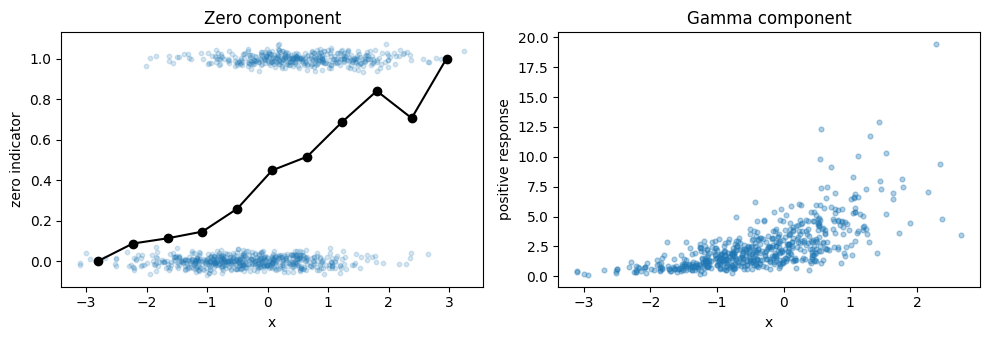

In [3]:
plot_rng = np.random.default_rng(1001)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

jitter = plot_rng.normal(scale=0.025, size=n_zero)
axes[0].scatter(x_zero, zero_count + jitter, s=10, alpha=0.18)

bins = np.linspace(x_zero.min(), x_zero.max(), 12)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
zero_rates = [
    zero_count[(x_zero >= lo) & (x_zero < hi)].mean()
    for lo, hi in zip(bins[:-1], bins[1:])
]
axes[0].plot(bin_centers, zero_rates, color="black", marker="o", linewidth=1.5)
axes[0].set_xlabel("x")
axes[0].set_ylabel("zero indicator")
axes[0].set_title("Zero component")

axes[1].scatter(X_pos[:, 1], y_pos, s=12, alpha=0.35)
axes[1].set_xlabel("x")
axes[1].set_ylabel("positive response")
axes[1].set_title("Gamma component")
plt.tight_layout()
plt.show()

## Build the branch model

The two likelihood branches share one Liesel model but use separate parameter blocks. The zero branch owns `alpha_zero`; the positive branch owns `beta_pos` and `log_concentration`. The positive branch has its own observed design matrix `X_pos` and response `y_pos`, both with `n_positive` rows.

In [4]:
X_zero_jax = jnp.asarray(X_zero)
zero_count_jax = jnp.asarray(zero_count)
X_pos_jax = jnp.asarray(X_pos)
y_pos_jax = jnp.asarray(y_pos)

alpha_zero = lsl.Var.new_param(
    jnp.zeros(X_zero_jax.shape[1]),
    lsl.Dist(tfd.Normal, loc=0.0, scale=5.0),
    name="alpha_zero",
)
X0 = lsl.Var.new_obs(X_zero_jax, name="X_zero")
zero_logit = lsl.Var.new_calc(
    lambda X, alpha: X @ alpha,
    X0,
    alpha_zero,
    name="zero_logit",
)
zero = lsl.Var.new_obs(
    zero_count_jax,
    lsl.Dist(tfd.Binomial, total_count=1.0, logits=zero_logit),
    name="zero_count",
)

beta_pos = lsl.Var.new_param(
    jnp.zeros(X_pos_jax.shape[1]),
    lsl.Dist(tfd.Normal, loc=0.0, scale=5.0),
    name="beta_pos",
)
log_concentration = lsl.Var.new_param(
    jnp.array(0.0),
    lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="log_concentration",
)
concentration = lsl.Var.new_calc(jnp.exp, log_concentration, name="concentration")
Xp = lsl.Var.new_obs(X_pos_jax, name="X_pos")
eta_pos = lsl.Var.new_calc(
    lambda X, beta: X @ beta,
    Xp,
    beta_pos,
    name="eta_pos",
)
mean_pos_var = lsl.Var.new_calc(jnp.exp, eta_pos, name="mean_pos")
rate_pos = lsl.Var.new_calc(
    lambda concentration, mean: concentration / mean,
    concentration,
    mean_pos_var,
    name="rate_pos",
)
y_positive = lsl.Var.new_obs(
    y_pos_jax,
    lsl.Dist(tfd.Gamma, concentration=concentration, rate=rate_pos),
    name="y_pos",
)

model = lsl.Model([zero, y_positive])
{
    "parameters": list(model.parameters),
    "observed": list(model.observed),
}

{'parameters': ['beta_pos', 'log_concentration', 'alpha_zero'],
 'observed': ['X_pos', 'X_zero', 'zero_count', 'y_pos']}

## Split the two branches

`PositionSplit.from_model(..., multi_size="manager")` returns a `PositionSplitManager` because the observed position entries have two different sample sizes. The zero branch contains `X_zero` and `zero_count`; the positive branch contains `X_pos` and `y_pos`. Both branches use axis `0`, so no custom axis mapping is needed here.

In [5]:
observed_keys = ["X_zero", "zero_count", "X_pos", "y_pos"]

split = opt.PositionSplit.from_model(
    model,
    position_keys=observed_keys,
    share_validate=0.2,
    share_test=0.1,
    default_axis=0,
    shuffle=True,
    seed=123,
    multi_size="manager",
)

split

PositionSplitManager(n=(1000, 596), train=(700, 418), validate=(200, 119), test=(100, 59))

In [6]:
pd.DataFrame(
    [
        {
            "keys": ", ".join(child.position_keys),
            "n": child.n,
            "train": child.n_train,
            "validate": child.n_validate,
            "test": child.n_test,
        }
        for child in split.splits
    ]
)

,keys,n,train,validate,test
0,"X_zero, zero_count",1000,700,200,100
1,"X_pos, y_pos",596,418,119,59


## Two optimizers and learning-rate schedulers

`OptimEngine` can run several optimizers in sequence for every batch. Their `position_keys` must be disjoint. Here, the zero-component coefficients use one Adam optimizer and the positive gamma parameters use another.

In [7]:
zero_schedule = optax.exponential_decay(
    init_value=3e-2,
    transition_steps=30,
    decay_rate=0.9,
    end_value=3e-4,
)
positive_schedule = optax.exponential_decay(
    init_value=2e-2,
    transition_steps=30,
    decay_rate=0.92,
    end_value=5e-4,
)

zero_optimizer = opt.Optimizer(
    ["alpha_zero"],
    optax.chain(optax.clip_by_global_norm(10.0), optax.adam(zero_schedule)),
    identifier="zero_adam",
)
positive_optimizer = opt.Optimizer(
    ["beta_pos", "log_concentration"],
    optax.chain(optax.clip_by_global_norm(10.0), optax.adam(positive_schedule)),
    identifier="positive_adam",
)

schedule_steps = [0, 30, 60, 120, 240]
pd.DataFrame(
    {
        "step": schedule_steps,
        "zero_learning_rate": [float(zero_schedule(step)) for step in schedule_steps],
        "positive_learning_rate": [
            float(positive_schedule(step)) for step in schedule_steps
        ],
    }
)

,step,zero_learning_rate,positive_learning_rate
0,0,0.030,0.020
1,30,0.027,0.018
2,60,0.024,0.017
3,120,0.020,0.014
4,240,0.013,0.010


## Build and inspect the engine

Passing the `PositionSplitManager` to `LieselOptim` makes the batching side use a `BatchManager`. Each child split receives its own mini-batches, and the manager combines them into a joint optimization step.

In [8]:
engine = opt.LieselOptim(
    model,
    split=split,
    batch_size=96,
    default_axis=0,
    optimizers=[zero_optimizer, positive_optimizer],
    stopper=opt.Stopper(epochs=250, patience=40, rtol=5e-4),
    seed=321,
).build_engine()
engine.show_progress = False

{
    "batching": repr(engine.batches),
    "n": engine.batches.n,
    "batch_size": engine.batches.batch_size,
    "n_full_batches": engine.batches.n_full_batches,
    "optimizer_ids": [optimizer.identifier for optimizer in engine.optimizers],
}

{'batching': "BatchManager(n=(700, 418), batch_size=(96, 96), mode='resample', n_full_batches=7)",
 'n': (700, 418),
 'batch_size': (96, 96),
 'n_full_batches': 7,
 'optimizer_ids': ['zero_adam', 'positive_adam']}

The `BatchManager` forms a joint epoch from branch-specific mini-batches. With `mode="resample"`, the shorter positive branch can reuse child batch rows so that both optimizer blocks still see a joint batch at every step.

In [9]:
result = engine.fit()
result

OptimResult(final_epoch=71, best_epoch=58, duration=0.9s)

## Inspect the fitted parameters

In [10]:
position = result.best_position

rows = [
    {
        "parameter": f"alpha_zero[{i}]",
        "estimate": float(position["alpha_zero"][i]),
        "truth": float(truth),
    }
    for i, truth in enumerate(alpha_zero_true)
]
rows += [
    {
        "parameter": f"beta_pos[{i}]",
        "estimate": float(position["beta_pos"][i]),
        "truth": float(truth),
    }
    for i, truth in enumerate(beta_pos_true)
]
rows += [
    {
        "parameter": "concentration",
        "estimate": float(jnp.exp(position["log_concentration"])),
        "truth": float(concentration_true),
    }
]

pd.DataFrame(rows)

,parameter,estimate,truth
0,alpha_zero[0],-0.508,-0.550
1,alpha_zero[1],1.089,1.100
2,alpha_zero[2],-0.692,-0.800
3,beta_pos[0],0.983,1.000
4,beta_pos[1],0.636,0.650
5,beta_pos[2],-0.346,-0.350
6,concentration,5.127,5.000


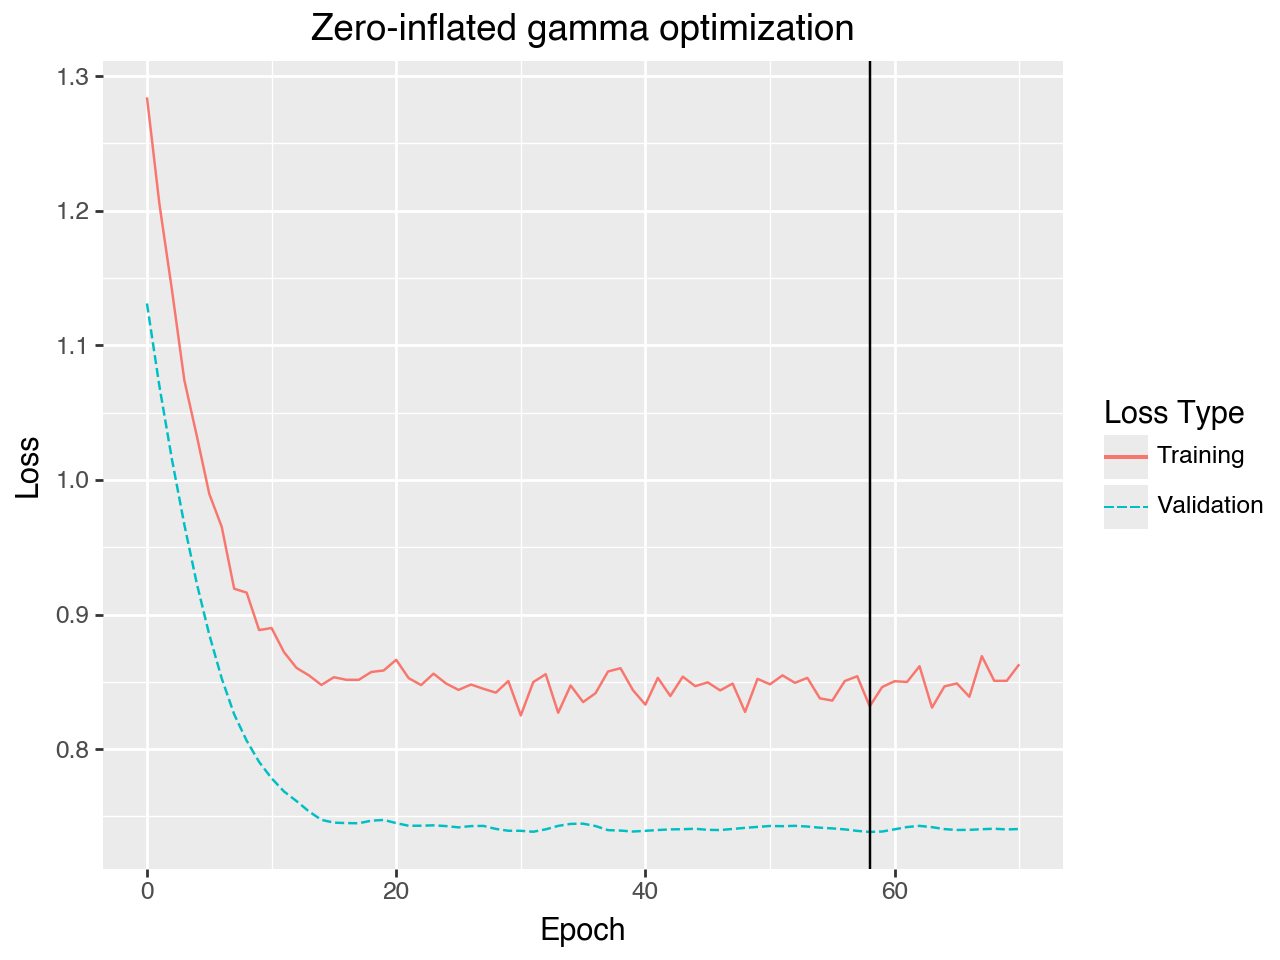

In [11]:
result.plot_loss(title="Zero-inflated gamma optimization")

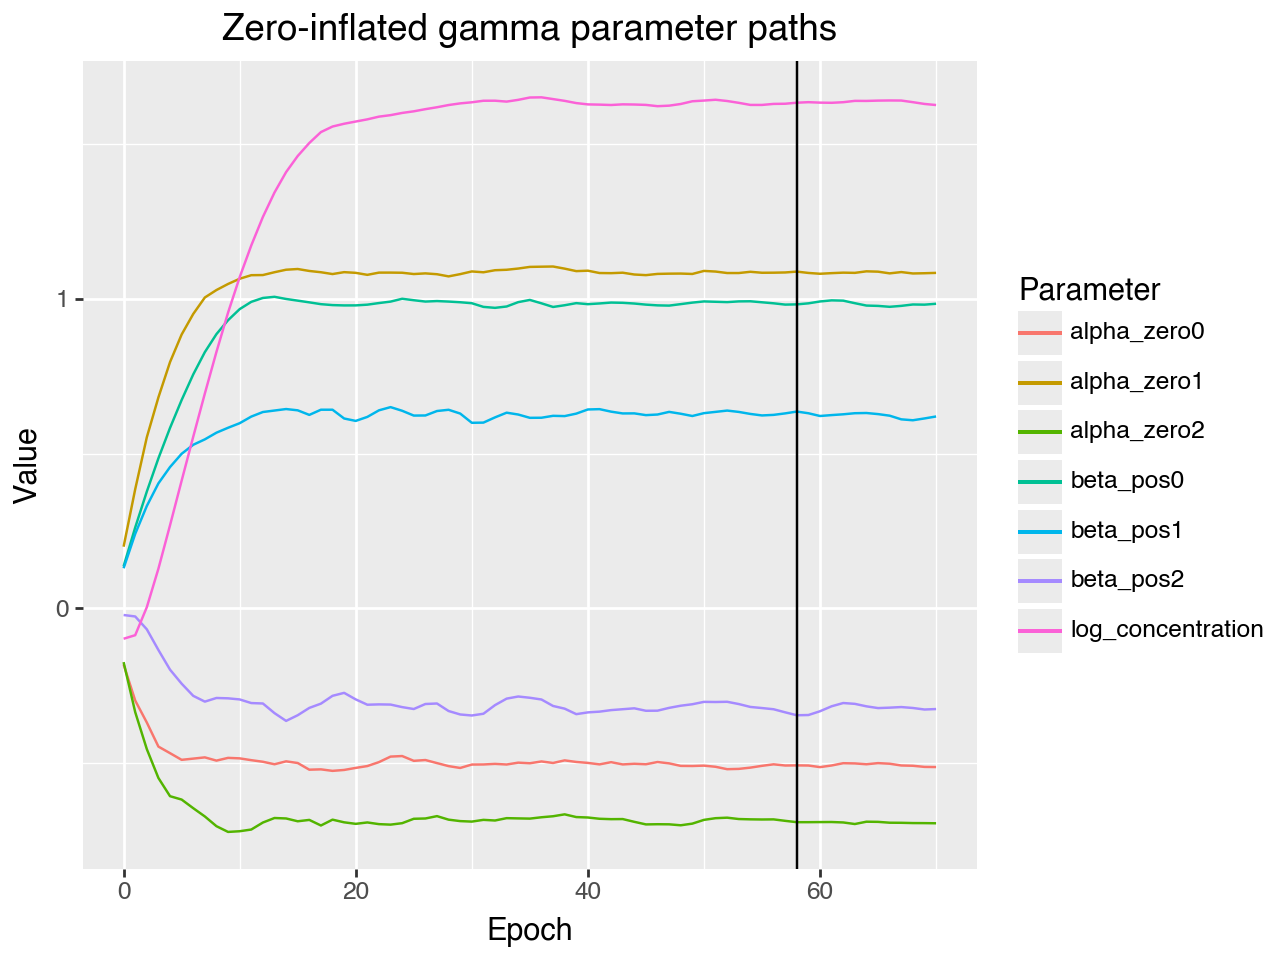

In [12]:
result.plot_params(
    title="Zero-inflated gamma parameter paths",
    subset=["alpha_zero", "beta_pos", "log_concentration"],
)

## Held-out test loss

For a `PositionSplitManager`, `scaled_log_lik()` applies the correct branch-specific scaling internally. The scalar used by the default scaled loss is the total training size across branches.

In [13]:
test_state = model.update_state(result.best_position | split.test, model.state)
test_loss = float(
    -split.scaled_log_lik(model, test_state, part="test") / sum(split.n_trains)
)

pd.DataFrame(
    {
        "best_epoch": [result.best_epoch],
        "final_epoch": [result.final_epoch],
        "test_loss": [test_loss],
    }
)

,best_epoch,final_epoch,test_loss
0,58,71,0.810


## Predictions by branch

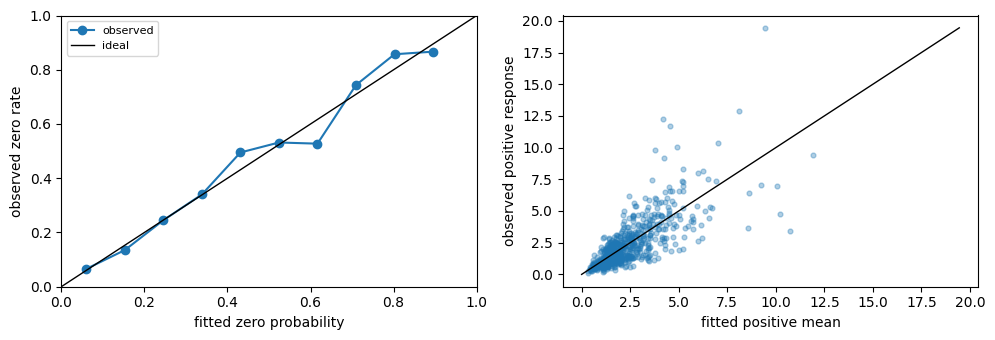

In [14]:
position = result.best_position

alpha_hat = np.asarray(position["alpha_zero"])
zero_prob_hat = 1.0 / (1.0 + np.exp(-(X_zero @ alpha_hat)))

beta_hat = np.asarray(position["beta_pos"])
positive_mean_hat = np.exp(X_pos @ beta_hat)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

prob_bins = np.linspace(zero_prob_hat.min(), zero_prob_hat.max(), 11)
prob_centers = 0.5 * (prob_bins[:-1] + prob_bins[1:])
empirical_zero_rates = [
    zero_count[(zero_prob_hat >= lo) & (zero_prob_hat < hi)].mean()
    for lo, hi in zip(prob_bins[:-1], prob_bins[1:])
]
axes[0].plot(prob_centers, empirical_zero_rates, marker="o", label="observed")
axes[0].plot([0.0, 1.0], [0.0, 1.0], color="black", linewidth=1.0, label="ideal")
axes[0].set_xlim(0.0, 1.0)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_xlabel("fitted zero probability")
axes[0].set_ylabel("observed zero rate")
axes[0].legend(fontsize=8)

axes[1].scatter(positive_mean_hat, y_pos, s=12, alpha=0.35)
limit = max(float(positive_mean_hat.max()), float(y_pos.max()))
axes[1].plot([0.0, limit], [0.0, limit], color="black", linewidth=1.0)
axes[1].set_xlabel("fitted positive mean")
axes[1].set_ylabel("observed positive response")

plt.tight_layout()
plt.show()